MS 263 Final Project

Assessing the Bacterial Community Composition of a Pesticide-Remediating Bioreactor in Salinas Valley, CA

Lindsay Yue

Introduction

The Salinas River Valley is a major agricultural region on the California Central Coast, growing crops such as strawberries, lettuce, and brassicas (1). However, pesticides such as neonicotinoids, organophosphates, and pyrethroids are commonly applied, and are transported to nearby surface waters through agricultural runoff (1). In the Central Coast region, monitoring reveals widespread pesticide contamination, with multiple pesticides detected in most sites, often at concentrations above the EPA chronic-invertebrate threshold (2). In the Santa Maria River estuary, runoff and sediment containing chlorpyrifos and pyrethroids were toxic to invertebrates, and benthic stream communities were dominated by pollution tolerant taxa (3). Laboratory exposure to imidacloprid and chlorantraniliprole caused Daphnia magna mortality and altered gene expression in Pimephales promelas (4). In the Salinas Valley, women in closer residential proximity to pesticide application areas had increased cardiovascular risk factors (5).

A practical approach to reducing pesticide pollution is to treat agricultural wastewater on-site. Woodchip bioreactors are a bioremediation method commonly used to reduce nitrates through metabolic activity of resident microbial communities (6). Extensive research exists on nitrate bioremediation in these bioreactors (6), but less is known about their potential for pesticide removal. Existing research on pesticide bioremediation focuses on sorption, hydraulic retention times and characterizing naturally occurring bacterial communities (7, 8).

Microbial communities can respond to pollutants, such as pesticides. Soil communities exposed to pesticides have lower diversity, different dominant taxa, and altered metabolic pathways (9, 10). French et al. (2020) (11) showed that E. coli engineered with petroleum hydrocarbon degradation genes added to contaminated soil horizontally transferred those genes to naturally occurring bacteria. Transferred genes persisted for over 60 days, and petroleum concentrations in the soil decreased by 46% (11). In groundwater contaminated with heavy metals and nitrates, horizontal gene transfer of heavy metal resistance, but not denitrifying genes occurred, suggesting not all functional genes are equally likely to be transferred (12).

In the Jue lab at CSUMB, preliminary research shows reduced imidacloprid concentrations after remediators were added to a woodchip bioreactor, but remediators do not dominate the community (13). It remains unknown whether horizontal gene transfer occurs, and if native taxa contribute to pesticide degradation. My project will use 16S sequencing data to characterize microbial community composition in the bioreactor. My objectives are:

1) Does bacterial community composition of the bioreactor change after pesticide-remediating
bacteria are added? 
2) Is bacterial community composition different between port 1 (inflow) and port 4 (outflow) of the bioreactor?
3) Is bacterial community composition different in 2019 and 2024? 

These findings will improve bioreactor design and reveal how bacterial communities adapt to environmental stressors such as pesticide pollution.


Methods

Field Experiments
To characterize changes in bacterial community composition in the bioreactor, field experiments were conducted during the 2019 and 2024 growing season at a bioreactor installed in the Salinas Valley. Sediment and water column samples were collected from the bioreactor for bacterial genomics analysis, and water quality parameters which included temperature, conductivity, salinity, dissolved oxygen, nitrate and turbidity were measured using a ProDSS instrument. 

Molecular Lab Work
DNA from water and sediment samples was isolated using the DNeasy PowerSoil Pro and DNeasy PowerWater Sterivex kits from Qiagen. Afterwards, the 16S gene amplicons were sequenced using an Illumina MiSeq system.

Computational Work and Data Analysis
16S data was analyzed using QIIME 2 (14) to identify amplicon sequence variants and taxonomically classify samples. From this processing, OTU tables were created. The OTU tables and sample metadata are the datasets used in this project. 

Import necessary packages

In [21]:
#Data manipulation
import pandas as pd

#Calculating alpha diversity
from skbio.diversity import alpha_diversity

#Plotting
import seaborn as sns
import matplotlib.pyplot as plt

#Statistical Analyses
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu

Import rarefied OTU datasets that were previously generated using QIIME 2 and R, and sample metadata.

In [24]:
BR19_OTU=pd.read_csv("BR19_OTUs_rarefied_copy.csv", index_col=0)
BR24_OTU=pd.read_csv("BR24_OTUs_rarefied_copy.csv", index_col=0)

BR19_md = pd.read_csv('BR_2019_metadata copy.tsv', sep='\t', index_col=0)
BR24_md = pd.read_csv('BR2024_metadata_F240_R220 copy.tsv', sep='\t', index_col=0)

For BR19, I only want to analyze ports 1 and 4, so I will filter out samples collected at ports 2 and 3.

In [25]:
final_BR19[(final_BR19["SampleType"] == "Water")]
BR19_md = BR19_md[(BR19_md["Port"] == 1) | (BR19_md["Port"] == 4)]

Create the final datasets. This will include a dataframe that includes samples with rarefied OTUs, metadata, and alpha diversity metrics. This is done using the Final_dataset.py module.

The Final_dataset module contains the function merged_data. For this function, the metadata and rarefied OTU table are required inputs. The rarefied OTU tables contain only the samples that were rarefied at 1000 reads. This accounts for uneven sequencing depth. Samples containing less than 1000 reads were discarded, and samples that had 1000 or more reads were subsampled 1000 times. From these rarefied OTU tables, the alpha diversity metrics, Shannon Diversitiy and Sobs (OTUs observed) were calculated and then merged with the rarefied OTUs and metadata. This was done with the 2019 and 2024 datasets.


In [27]:
from Final_dataset import merged_data
final_BR19 = merged_data(BR19_OTU, BR19_md)
final_BR24 = merged_data(BR24_OTU, BR24_md)


In [31]:
#Separate out water and sediment from datasets
#By year
water19 = final_BR19[(final_BR19["SampleType"] == "Water")]
sed19 = final_BR19[(final_BR19["SampleType"] == "Sediment")]
water24 = final_BR24[(final_BR24["SampleType"] == "Water")]
sed24 = final_BR24[(final_BR24["SampleType"] == "Sediment")]

#Including both years
water=pd.concat([water19, water24], axis=0)
sediment=pd.concat([sed19, sed24], axis = 0)

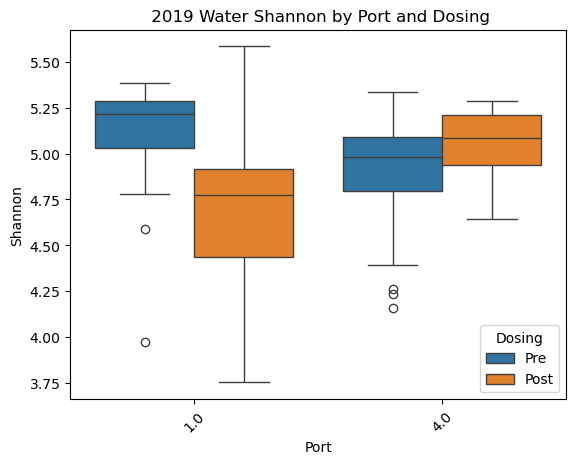

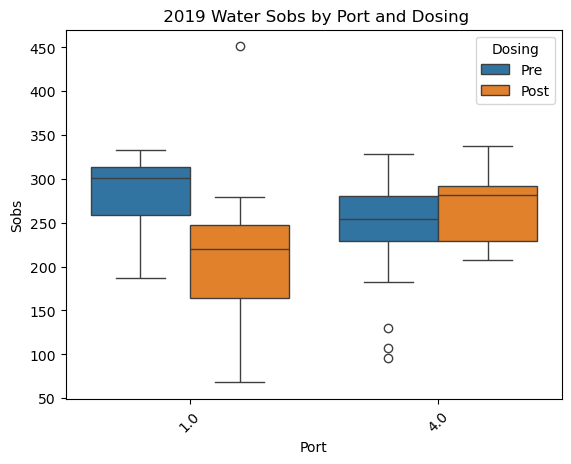

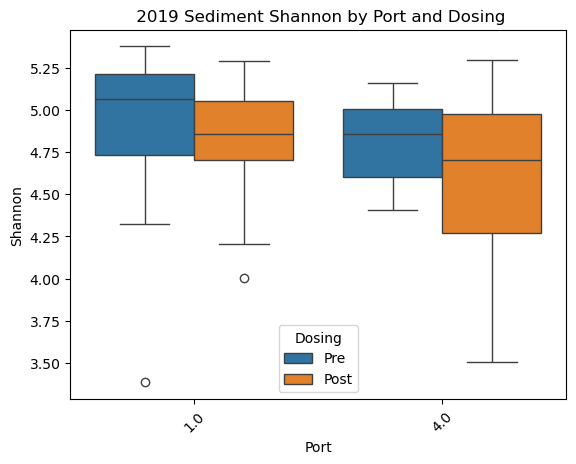

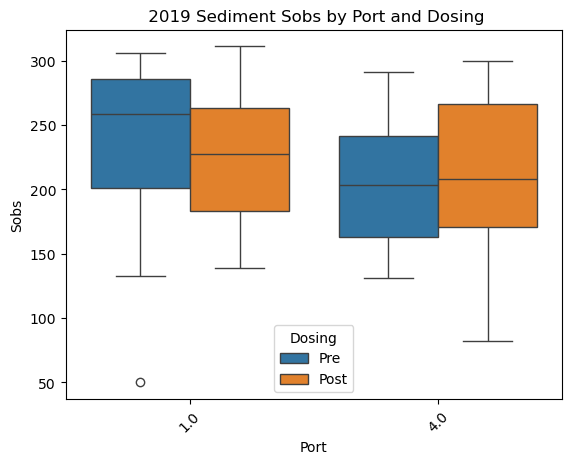

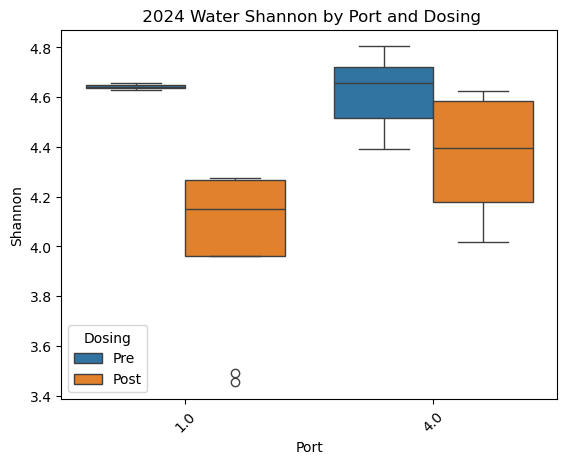

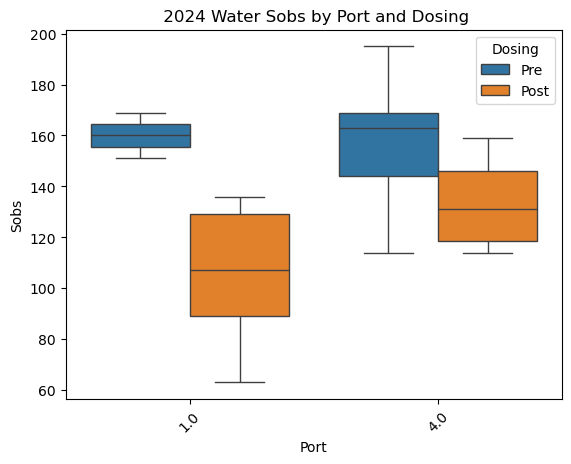

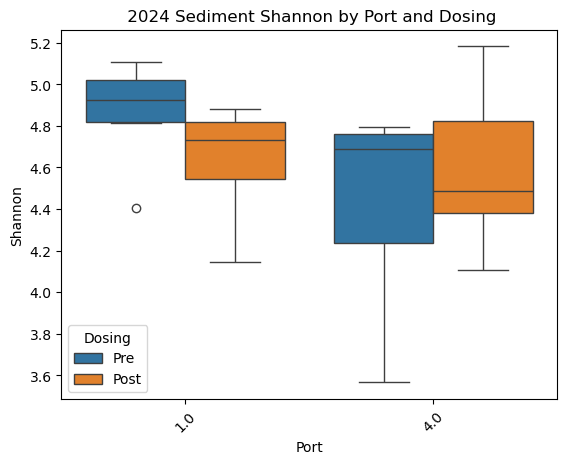

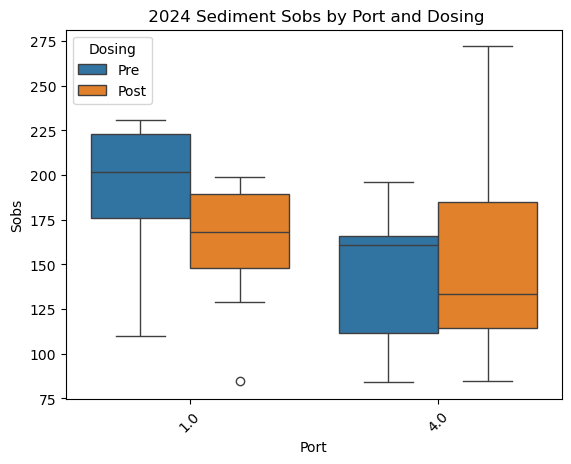

In [32]:
#Boxplots 2019 and 2024, loop new structure
plot_variables = ['Shannon', 'Sobs']

datasets = {
    "2019 Water": water19,
    "2019 Sediment": sed19,
    "2024 Water": water24,
    "2024 Sediment": sed24
}
for dataset_name, dataset in datasets.items():
    for var in plot_variables:
        plt.figure()

        sns.boxplot(data=dataset, x='Port', y=var, hue = 'Dosing')

        
        plt.title(f" {dataset_name} {var} by Port and Dosing")
        plt.xlabel("Port")
        plt.ylabel(var)
        plt.xticks(rotation=45)
        plt.savefig(f" {dataset_name} {var} by Port and Dosing") 
        plt.show()

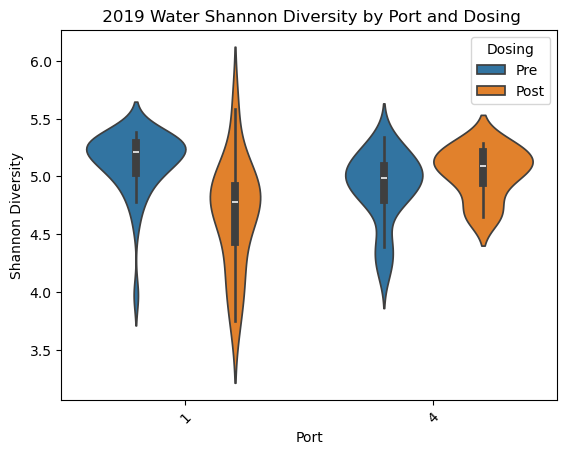

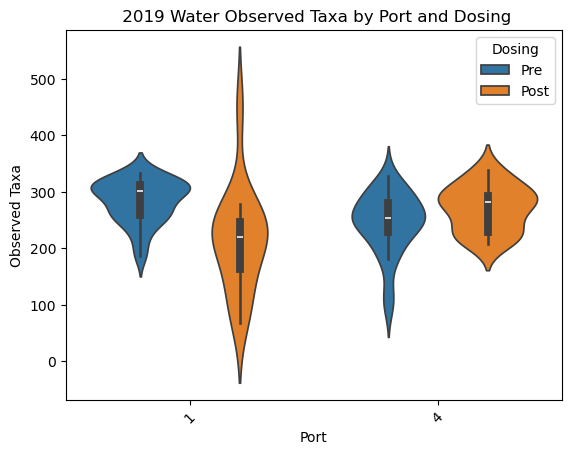

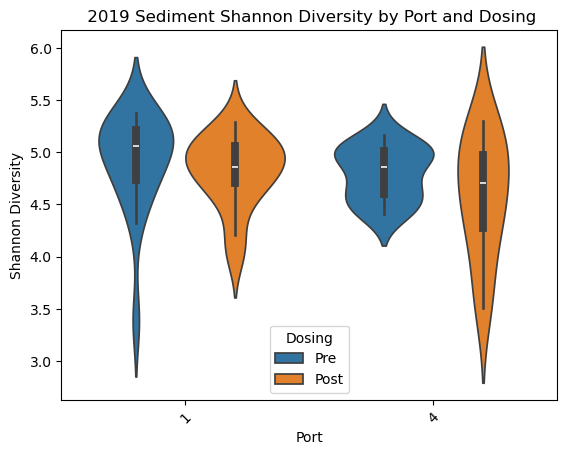

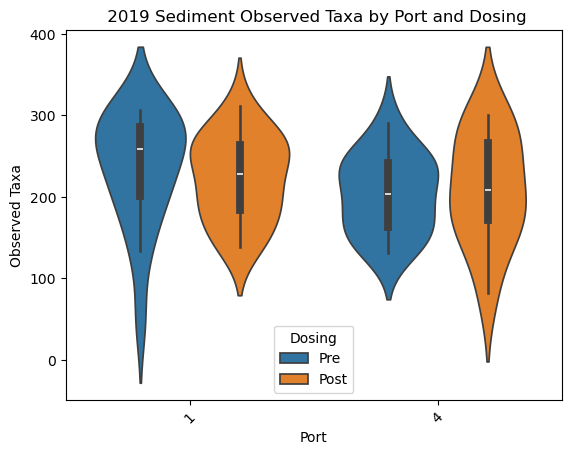

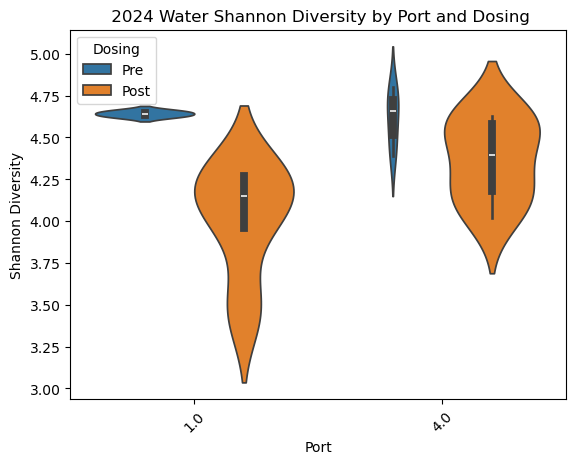

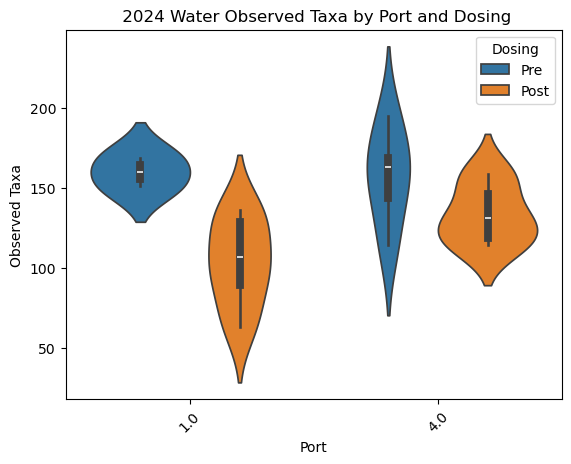

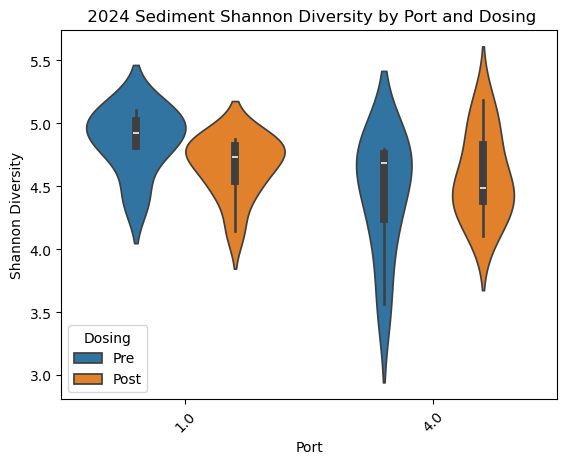

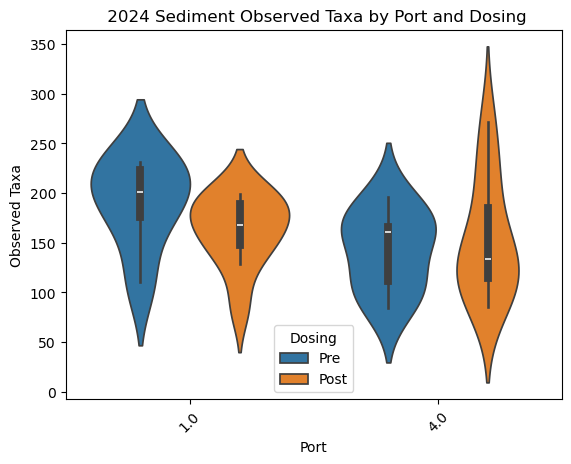

In [97]:
#Violin plots new structure
#violin 2019 and 2024, new structure
plot_variables = ['Shannon', 'Sobs']

labels = {
    'Shannon': 'Shannon Diversity',
    'Sobs': 'Observed Taxa'
}

datasets = {
    "2019 Water": water19,
    "2019 Sediment": sed19,
    "2024 Water": water24,
    "2024 Sediment": sed24
}
for dataset_name, dataset in datasets.items():
    for var in plot_variables:
        plt.figure()

        sns.violinplot(data=dataset, x='Port', y=var, hue = 'Dosing', inner='box')

        
        plt.title(f" {dataset_name} {labels[var]} by Port and Dosing")
        plt.xlabel("Port")
        plt.ylabel(labels[var])
        plt.xticks(rotation=45)
        plt.savefig(f" {dataset_name} {labels[var]} by Port and Dosing Violin Plot") 
        plt.show()

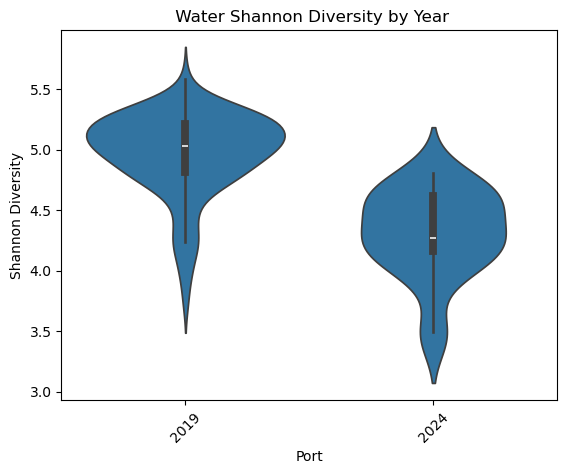

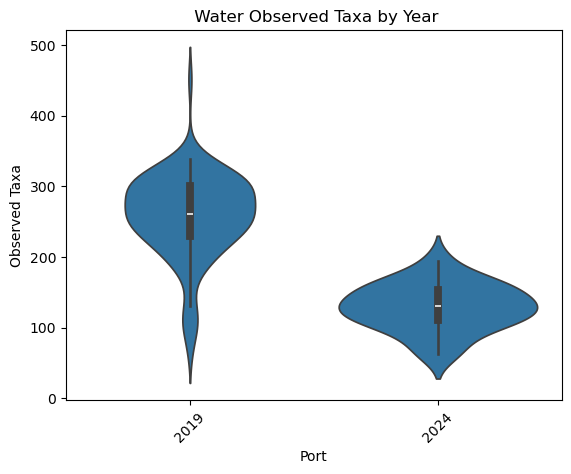

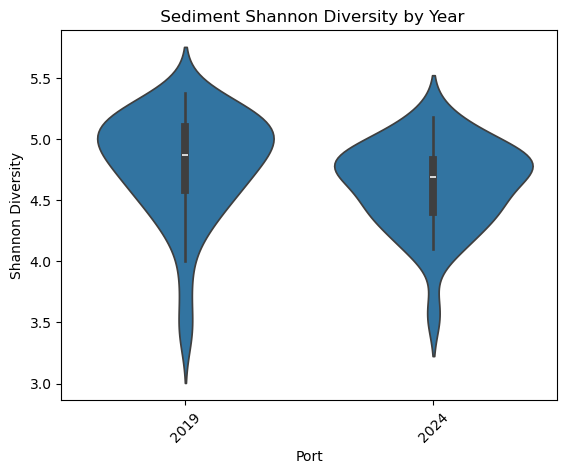

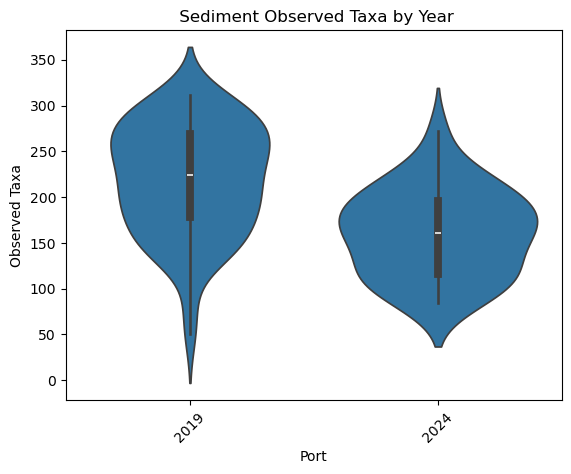

In [11]:
#Violin plots new structure yr
#violin 2019 and 2024, new structure
plot_variables = ['Shannon', 'Sobs']

labels = {
    'Shannon': 'Shannon Diversity',
    'Sobs': 'Observed Taxa'
}

datasets = {
    "Water": waterall,
    "Sediment": sedimentall
}
for dataset_name, dataset in datasets.items():
    for var in plot_variables:
        plt.figure()

        sns.violinplot(data=dataset, x='Year', y=var, inner='box')

        
        plt.title(f" {dataset_name} {labels[var]} by Year")
        plt.xlabel("Port")
        plt.ylabel(labels[var])
        plt.xticks(rotation=45)
        plt.savefig(f" {dataset_name} {labels[var]} by Year Violin Plot") 
        plt.show()

Test for normality, using Shapiro-Wilk Test

In [35]:
print("BR19 Shannon", shapiro(final_BR19['Shannon']))
print("BR19 Sobs", shapiro(final_BR19['Sobs']))
print("BR24 Shannon", shapiro(final_BR24['Shannon']))
print("BR24 Sobs", shapiro(final_BR24['Sobs']))
#p value significant, so data not normally distributed and need to use nonparametric tests

#Do this for other combos you'll test
#2019 v 2024
print("Water Shannon", shapiro(water['Shannon']))
print("Water Sobs", shapiro(water['Sobs']))
print("Sediment Shannon", shapiro(sediment['Shannon']))
print("Sediment Sobs", shapiro(sediment['Sobs']))

#Most p values significant, so most datasets not normally distributed


BR19 Shannon ShapiroResult(statistic=np.float64(0.8636087406586965), pvalue=np.float64(1.4849638876857445e-16))
BR19 Sobs ShapiroResult(statistic=np.float64(0.9738592978338027), pvalue=np.float64(9.48392845670778e-06))
BR24 Shannon ShapiroResult(statistic=np.float64(0.7595428679991516), pvalue=np.float64(6.120283627678839e-21))
BR24 Sobs ShapiroResult(statistic=np.float64(0.6696173702311649), pvalue=np.float64(4.089694361344592e-24))
Water Shannon ShapiroResult(statistic=np.float64(0.9127267504178972), pvalue=np.float64(4.242843536628731e-07))
Water Sobs ShapiroResult(statistic=np.float64(0.9444095064375227), pvalue=np.float64(4.6254450298213174e-05))
Sediment Shannon ShapiroResult(statistic=np.float64(0.9309793484289742), pvalue=np.float64(0.00011230759965362617))
Sediment Sobs ShapiroResult(statistic=np.float64(0.980242698232329), pvalue=np.float64(0.1768677035111586))


In [39]:
#Mann whitney u tests
#Testing Dosing and Port
plot_variables = ['Shannon', 'Sobs']

labels = {
    'Shannon': 'Shannon Diversity',
    'Sobs': 'Observed Taxa'
}

datasets = {
    "2019 Water": water19,
    "2019 Sediment": sed19,
    "2024 Water": water24,
    "2024 Sediment": sed24
}

results = []

for dataset_name, dataset in datasets.items():
    for var in plot_variables:
        port1 = dataset[dataset['Port'] == 1][var]
        port4 = dataset[dataset['Port'] == 4][var]

        stat_port, p_port = mannwhitneyu(port1, port4, alternative="two-sided")
        
        results.append({
            "Dataset": dataset_name,
            "Metric": labels[var],
            "Test": "Port 1 vs Port 4",
            "Group1_n": len(port1),
            "Group2_n": len(port4),
            "U_stat": stat_port,
            "p_value": p_port
        })

 # --- Pre vs Post dosing ---
        pre = dataset[dataset['Dosing'] == 'Pre'][var]
        post = dataset[dataset['Dosing'] == 'Post'][var]
        
        stat_dose, p_dose = mannwhitneyu(pre, post, alternative="two-sided")

        results.append({
            "Dataset": dataset_name,
            "Metric": labels[var],
            "Test": "Pre vs Post Dosing",
            "Group1_n": len(pre),
            "Group2_n": len(post),
            "U_stat": stat_dose,
            "p_value": p_dose
        })

results_df = pd.DataFrame(results)

results_df




,Dataset,Metric,Test,Group1_n,Group2_n,U_stat,p_value
0,2019 Water,Shannon Diversity,Port 1 vs Port 4,52,54,1672.0,0.090926
1,2019 Water,Shannon Diversity,Pre vs Post Dosing,74,32,1536.0,0.015564
2,2019 Water,Observed Taxa,Port 1 vs Port 4,52,54,1631.0,0.152216
3,2019 Water,Observed Taxa,Pre vs Post Dosing,74,32,1465.0,0.053507
4,2019 Sediment,Shannon Diversity,Port 1 vs Port 4,34,25,539.0,0.081682
5,2019 Sediment,Shannon Diversity,Pre vs Post Dosing,32,27,508.0,0.250681
6,2019 Sediment,Observed Taxa,Port 1 vs Port 4,34,25,532.0,0.102305
7,2019 Sediment,Observed Taxa,Pre vs Post Dosing,32,27,452.0,0.766689
8,2024 Water,Shannon Diversity,Port 1 vs Port 4,11,12,32.0,0.039228
9,2024 Water,Shannon Diversity,Pre vs Post Dosing,7,16,105.0,0.000367


In [40]:
#Testing Year

plot_variables = ['Shannon', 'Sobs']

labels = {
    'Shannon': 'Shannon Diversity',
    'Sobs': 'Observed Taxa'
}

results_year = []

# Water: 2019 vs 2024
for var in plot_variables:
    y2019 = water19[var].dropna()
    y2024 = water24[var].dropna()

    stat, p = mannwhitneyu(y2019, y2024, alternative="two-sided")

    results_year.append({
        "Dataset": "Water",
        "Metric": labels[var],
        "Test": "2019 vs 2024",
        "n_2019": len(y2019),
        "n_2024": len(y2024),
        "U_stat": stat,
        "p_value": p
    })

# Sediment: 2019 vs 2024
for var in plot_variables:
    y2019 = sed19[var].dropna()
    y2024 = sed24[var].dropna()

    stat, p = mannwhitneyu(y2019, y2024, alternative="two-sided")

    results_year.append({
        "Dataset": "Sediment",
        "Metric": labels[var],
        "Test": "2019 vs 2024",
        "n_2019": len(y2019),
        "n_2024": len(y2024),
        "U_stat": stat,
        "p_value": p
    })

results_year_df = pd.DataFrame(results_year)
results_year_df

,Dataset,Metric,Test,n_2019,n_2024,U_stat,p_value
0,Water,Shannon Diversity,2019 vs 2024,106,23,2241.0,3.267808e-10
1,Water,Observed Taxa,2019 vs 2024,106,23,2318.0,1.377343e-11
2,Sediment,Shannon Diversity,2019 vs 2024,59,33,1295.0,8.970108e-03
3,Sediment,Observed Taxa,2019 vs 2024,59,33,1514.0,1.100891e-05


In [42]:
#welch t year

from scipy.stats import ttest_ind
import pandas as pd

plot_variables = ['Shannon', 'Sobs']

labels = {
    'Shannon': 'Shannon Diversity',
    'Sobs': 'Observed Taxa'
}

results_year = []

# Water: 2019 vs 2024
for var in plot_variables:
    y2019 = water19[var].dropna()
    y2024 = water24[var].dropna()

    stat, p = ttest_ind(y2019, y2024, equal_var=False)  # Welch's t-test

    results_year.append({
        "Dataset": "Water",
        "Metric": labels[var],
        "Test": "2019 vs 2024",
        "n_2019": len(y2019),
        "n_2024": len(y2024),
        "t_stat": stat,
        "p_value": p
    })

# Sediment: 2019 vs 2024
for var in plot_variables:
    y2019 = sed19[var].dropna()
    y2024 = sed24[var].dropna()

    stat, p = ttest_ind(y2019, y2024, equal_var=False)  # Welch's t-test

    results_year.append({
        "Dataset": "Sediment",
        "Metric": labels[var],
        "Test": "2019 vs 2024",
        "n_2019": len(y2019),
        "n_2024": len(y2024),
        "t_stat": stat,
        "p_value": p
    })

results_year_df = pd.DataFrame(results_year)
results_year_df

,Dataset,Metric,Test,n_2019,n_2024,t_stat,p_value
0,Water,Shannon Diversity,2019 vs 2024,106,23,8.126896,3.430314e-09
1,Water,Observed Taxa,2019 vs 2024,106,23,14.538363,6.410923e-21
2,Sediment,Shannon Diversity,2019 vs 2024,59,33,2.091060,3.974029e-02
3,Sediment,Observed Taxa,2019 vs 2024,59,33,5.171316,1.695473e-06


In [43]:
#welch t port and dosing
from scipy.stats import ttest_ind
import pandas as pd

plot_variables = ['Shannon', 'Sobs']

labels = {
    'Shannon': 'Shannon Diversity',
    'Sobs': 'Observed Taxa'
}

datasets = {
    "2019 Water": water19,
    "2019 Sediment": sed19,
    "2024 Water": water24,
    "2024 Sediment": sed24
}

results = []

for dataset_name, dataset in datasets.items():
    for var in plot_variables:
        port1 = dataset[dataset['Port'] == 1][var]
        port4 = dataset[dataset['Port'] == 4][var]

        #Port 1 vs Port 4
        stat_port, p_port = ttest_ind(port1, port4, equal_var=False)  # equal_var=False makes it a Welch t-test
        
        results.append({
            "Dataset": dataset_name,
            "Metric": labels[var],
            "Test": "Port 1 vs Port 4",
            "Group1_n": len(port1),
            "Group2_n": len(port4),
            "t_stat": stat_port,
            "p_value": p_port
        })

        # Pre vs Post Dosing
        pre = dataset[dataset['Dosing'] == 'Pre'][var]
        post = dataset[dataset['Dosing'] == 'Post'][var]
        
        stat_dose, p_dose = ttest_ind(pre, post, equal_var=False)  # Welch

        results.append({
            "Dataset": dataset_name,
            "Metric": labels[var],
            "Test": "Pre vs Post Dosing",
            "Group1_n": len(pre),
            "Group2_n": len(post),
            "t_stat": stat_dose,
            "p_value": p_dose
        })

results_df = pd.DataFrame(results)

results_df

,Dataset,Metric,Test,Group1_n,Group2_n,t_stat,p_value
0,2019 Water,Shannon Diversity,Port 1 vs Port 4,52,54,0.723759,0.471033
1,2019 Water,Shannon Diversity,Pre vs Post Dosing,74,32,1.945251,0.057610
2,2019 Water,Observed Taxa,Port 1 vs Port 4,52,54,0.975847,0.331576
3,2019 Water,Observed Taxa,Pre vs Post Dosing,74,32,1.389279,0.171705
4,2019 Sediment,Shannon Diversity,Port 1 vs Port 4,34,25,1.495450,0.140993
5,2019 Sediment,Shannon Diversity,Pre vs Post Dosing,32,27,1.242807,0.219566
6,2019 Sediment,Observed Taxa,Port 1 vs Port 4,34,25,1.507997,0.137370
7,2019 Sediment,Observed Taxa,Pre vs Post Dosing,32,27,0.235623,0.814579
8,2024 Water,Shannon Diversity,Port 1 vs Port 4,11,12,-2.530065,0.021836
9,2024 Water,Shannon Diversity,Pre vs Post Dosing,7,16,4.651733,0.000137
